# Qlib 最小闭环示例 - 快速入门

本notebook展示了一个完整但最简化的Qlib量化投资工作流程，包括：
1. 环境初始化
2. 数据准备
3. 模型训练
4. 回测评估

整个流程约需5-10分钟完成。

## 第1步：安装和导入必要的库

In [1]:
# 如果未安装qlib，请先运行：
# !pip install pyqlib

import warnings
warnings.filterwarnings('ignore')

import qlib
import pandas as pd
import numpy as np

print(f"Qlib版本: {qlib.__version__}")
print("✅ 环境初始化完成")


Qlib版本: 0.9.7
✅ 环境初始化完成


## 第2步：初始化Qlib并下载数据

首次运行需要下载约1GB的中国A股数据，后续运行会自动跳过。

In [2]:
# 初始化Qlib
# provider_uri 指定数据存储位置
qlib.init(provider_uri="~/.qlib/qlib_data/cn_data")
print("✅ Qlib初始化成功")

[46992:MainThread](2025-10-19 05:38:14,291) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[46992:MainThread](2025-10-19 05:38:14,825) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[46992:MainThread](2025-10-19 05:38:14,826) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/zihao/.qlib/qlib_data/cn_data')}


✅ Qlib初始化成功


In [3]:
# 下载数据（仅首次需要）
from qlib.tests.data import GetData

# exists_skip=True 表示如果数据已存在则跳过下载
GetData().qlib_data(exists_skip=True)
print("✅ 数据准备完成")



2025-10-19 05:38:17.253 | WARNING  | qlib.tests.data:qlib_data:195 - Data already exists: ~/.qlib/qlib_data/cn_data, the data download will be skipped
	If downloading is required: `exists_skip=False` or `change target_dir`


✅ 数据准备完成


## 第3步：创建最简单的数据集

使用预定义的Alpha158特征集，包含158个技术指标。

In [4]:
from qlib.contrib.data.handler import Alpha158
from qlib.data.dataset import DatasetH

# 创建数据处理器
# 使用CSI300（沪深300）成分股作为股票池
handler = Alpha158(
    instruments="csi300",  # 股票池：沪深300成分股
    start_time="2018-01-01",  # 开始时间
    end_time="2020-12-31",    # 结束时间
    fit_start_time="2018-01-01",  # 数据标准化的起始时间
    fit_end_time="2018-12-31",    # 数据标准化的结束时间
)

# 创建数据集，划分训练集、验证集、测试集
dataset = DatasetH(
    handler,
    segments={
        "train": ("2018-01-01", "2018-12-31"),  # 训练集：2018年
        "valid": ("2019-01-01", "2019-12-31"),  # 验证集：2019年
        "test": ("2020-01-01", "2020-12-31"),   # 测试集：2020年
    }
)

print("✅ 数据集创建成功")

[46992:MainThread](2025-10-19 05:39:18,822) INFO - qlib.timer - [log.py:127] - Time cost: 61.527s | Loading data Done
[46992:MainThread](2025-10-19 05:39:18,937) INFO - qlib.timer - [log.py:127] - Time cost: 0.039s | DropnaLabel Done
[46992:MainThread](2025-10-19 05:39:19,248) INFO - qlib.timer - [log.py:127] - Time cost: 0.310s | CSZScoreNorm Done
[46992:MainThread](2025-10-19 05:39:19,248) INFO - qlib.timer - [log.py:127] - Time cost: 0.426s | fit & process data Done
[46992:MainThread](2025-10-19 05:39:19,248) INFO - qlib.timer - [log.py:127] - Time cost: 61.958s | Init data Done


✅ 数据集创建成功


In [5]:
# 获取Dataset并查看信息
train_data = dataset.prepare("train")
display(train_data.head())

valid_data = dataset.prepare("valid")
display(valid_data.head())

test_data = dataset.prepare("test")
display(test_data.head())



KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2018-01-02 SH600000    0.008723  0.013481  0.647058  0.003965  0.294121   
           SH600008    0.009709  0.017476  0.555557  0.003883  0.222221   
           SH600009   -0.013333  0.026667 -0.500002  0.007333  0.275001   
           SH600010    0.016260  0.024390  0.666668  0.004065  0.166666   
           SH600011    0.014563  0.022654  0.642858  0.004854  0.214285   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2018-01-02 SH600000    0.000793  0.058820  0.005551  0.411757  0.991352  ...   
           SH600008    0.003883  0.222221  0.009709  0.555557  0.990385  ...   
           SH600009    0.006000  0.224997 -0.014667 -0.550007  1.013514  ...   
           SH600010    0.004065  0.166666  0.016260  0.666668  0.984000  ...   
           SH600011    0.003236  0.142858  0.012945  0.571430  0.985646  ...   

                        VSUMN10   VSUMN20   VSUMN30   VSUMN60    VSUMD5  \
datetime   instrument                                                     
2018-01-02 SH600000    0.388162  0.508938  0.531578  0.509717  0.226996   
           SH600008    0.431804  0.484225  0.486605  0.507666  0.026581   
           SH600009    0.428595  0.468053  0.550978  0.510013  0.368400   
           SH600010    0.456158  0.531998  0.488363  0.494932 -0.113531   
           SH600011    0.510928  0.554349  0.498618  0.490071 -0.428183   

                        VSUMD10   VSUMD20   VSUMD30   VSUMD60    LABEL0  
datetime   instrument                                                    
2018-01-02 SH600000    0.223676 -0.017876 -0.063155 -0.019434  0.000000  
           SH600008    0.136393  0.031550  0.026790 -0.015332  0.015774  
           SH600009    0.142809  0.063894 -0.101957 -0.020025  0.001140  
           SH600010    0.087683 -0.063996  0.023274  0.010136 -0.004329  
           SH600011   -0.021856 -0.108698  0.002763  0.019859 -0.004576  

[5 rows x 159 columns]

KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2019-01-02 SH600000   -0.004107  0.021561 -0.190477  0.005133  0.238094   
           SH600004   -0.014925  0.026866 -0.555558  0.006965  0.259259   
           SH600009   -0.004348  0.019763 -0.219997  0.002372  0.120001   
           SH600010   -0.006757  0.020270 -0.333330  0.006757  0.333335   
           SH600011   -0.021769  0.069388 -0.313724  0.001361  0.019608   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2019-01-02 SH600000    0.012320  0.571430  0.003080  0.142859  1.004124  ...   
           SH600004    0.004975  0.185184 -0.016915 -0.629632  1.015152  ...   
           SH600009    0.013044  0.660002  0.006324  0.320004  1.004367  ...   
           SH600010    0.006757  0.333335 -0.006757 -0.333330  1.006803  ...   
           SH600011    0.046259  0.666667  0.023129  0.333334  1.022253  ...   

                        VSUMN10   VSUMN20   VSUMN30   VSUMN60    VSUMD5  \
datetime   instrument                                                     
2019-01-02 SH600000    0.471481  0.568959  0.493317  0.519958  0.026754   
           SH600004    0.685703  0.600891  0.506038  0.509799 -0.052968   
           SH600009    0.522480  0.569799  0.515875  0.535675  0.248437   
           SH600010    0.555342  0.583923  0.529433  0.562527 -0.016352   
           SH600011    0.480096  0.466168  0.476918  0.484489  0.639861   

                        VSUMD10   VSUMD20   VSUMD30   VSUMD60    LABEL0  
datetime   instrument                                                    
2019-01-02 SH600000    0.057037 -0.137918  0.013367 -0.039915  0.015294  
           SH600004   -0.371405 -0.201783 -0.012076 -0.019598  0.013616  
           SH600009   -0.044960 -0.139598 -0.031751 -0.071351  0.002401  
           SH600010   -0.110685 -0.167846 -0.058867 -0.125053  0.020259  
           SH600011    0.039808  0.067664  0.046164  0.031022  0.014398  

[5 rows x 159 columns]

KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2020-01-02 SH600000    0.000000  0.015237  0.000000  0.013633  0.894737   
           SH600004   -0.002278  0.012528 -0.181822  0.003417  0.272726   
           SH600009   -0.018025  0.022975 -0.784531  0.001650  0.071823   
           SH600010    0.000000  0.015038  0.000000  0.007519  0.500000   
           SH600011    0.005348  0.016043  0.333335  0.008913  0.555554   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2020-01-02 SH600000    0.001604  0.105263 -0.012029 -0.789473  1.000000  ...   
           SH600004    0.006834  0.545452  0.001139  0.090904  1.002283  ...   
           SH600009    0.003300  0.143646 -0.016375 -0.712709  1.018356  ...   
           SH600010    0.007519  0.500000  0.000000  0.000000  1.000000  ...   
           SH600011    0.001783  0.111112 -0.001782 -0.111107  0.994681  ...   

                        VSUMN10   VSUMN20   VSUMN30   VSUMN60    VSUMD5  \
datetime   instrument                                                     
2020-01-02 SH600000    0.422266  0.444089  0.480479  0.494528  0.675869   
           SH600004    0.363975  0.463199  0.498550  0.491700  1.000000   
           SH600009    0.258114  0.380129  0.423850  0.488858  0.932439   
           SH600010    0.573475  0.485106  0.483283  0.481801  0.180402   
           SH600011    0.299032  0.409221  0.409032  0.449196  0.870108   

                        VSUMD10   VSUMD20   VSUMD30   VSUMD60    LABEL0  
datetime   instrument                                                    
2020-01-02 SH600000    0.155468  0.111822  0.039042  0.010944 -0.011110  
           SH600004    0.272051  0.073602  0.002900  0.016599 -0.017387  
           SH600009    0.483772  0.239741  0.152301  0.022283 -0.022004  
           SH600010   -0.146950  0.029789  0.033434  0.036398  0.007162  
           SH600011    0.401936  0.181559  0.181935  0.101608  0.001529  

[5 rows x 159 columns]

## 第4步：训练一个简单的LightGBM模型

### **LightGBM 的核心思想**

LightGBM 是一种 **基于梯度提升（Gradient Boosting）的决策树模型**，核心流程是：

1. **Boosting 框架**

   * 按轮迭代训练一棵棵弱学习器（决策树），每一轮都试图拟合上一轮残差（即预测误差）。
   * 最终模型是多棵树的加权和即：

     $$
     \hat{y}_i = \sum_{t=1}^T f_t(x_i)
     $$

        * $\hat{y}_i$：第 $i$ 个样本（比如某天某只股票）的预测值
        * $T$：一共训练了 $T$ 棵树（弱学习器）
        * $f_t(x_i)$：第 $t$ 棵树对样本 $x_i$ 的预测值


2. **基于梯度的优化**

   * 在每一轮中，LightGBM会使用损失函数的一阶和二阶梯度信息，来选择最佳的分裂点（梯度提升）。

3. **基于直方图的决策树算法**

   * 将连续特征离散为固定数量的 bins，统计每个bin的梯度和二阶梯度，显著减少内存和计算量。

4. **Leaf-wise（叶子优先）生长策略**

   * 与 XGBoost 的 Level-wise 不同，LightGBM 总是优先扩展**增益最大的叶子节点**，能更快降低训练误差。

5. **其他优化**

   * 支持 GOSS（Gradient-based One-Side Sampling） 和 EFB（Exclusive Feature Bundling） 减少数据规模
   * 内建类别特征处理、缺失值处理

In [6]:
from qlib.contrib.model.gbdt import LGBModel

# 创建LightGBM模型（使用简化参数）
model = LGBModel(
    loss="mse", # 回归任务常用均方误差
    learning_rate=0.005, 
    max_depth=8, 
    num_leaves=32,
    verbosity=-1,  # 静默训练
    early_stopping_rounds=50,
    num_boost_round=100,
)

print("开始训练模型...")
model.fit(dataset)
print("✅ 模型训练完成")

ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).
ModuleNotFoundError.  PyTorch models are skipped (optional: maybe installing pytorch can fix it).
开始训练模型...
Training until validation scores don't improve for 50 rounds
[20]	train's l2: 0.99162	valid's l2: 0.995979
[40]	train's l2: 0.987369	valid's l2: 0.995558
[60]	train's l2: 0.983608	valid's l2: 0.995319
[80]	train's l2: 0.980115	valid's l2: 0.995197
[100]	train's l2: 0.976972	valid's l2: 0.995136
Did not meet early stopping. Best iteration is:
[99]	train's l2: 0.977117	valid's l2: 0.995129


[46992:MainThread](2025-10-19 05:39:23,069) INFO - qlib.workflow - [exp.py:258] - Experiment 473352165343310614 starts running ...
[46992:MainThread](2025-10-19 05:39:23,982) INFO - qlib.workflow - [recorder.py:345] - Recorder f6296e85020e4deea03d76dab4401c24 starts running under Experiment 473352165343310614 ...


✅ 模型训练完成


## 第5步：生成预测并查看结果

In [7]:
# 在测试集上生成预测
test_pred = model.predict(dataset, segment="test")

# 查看预测结果
# print(type(test_pred))
display(pd.DataFrame(test_pred).head(10))
display(pd.DataFrame(test_pred).describe())

0
datetime   instrument          
2020-01-02 SH600000    0.010218
           SH600004   -0.002994
           SH600009   -0.000524
           SH600010   -0.001527
           SH600011    0.000155
           SH600015    0.037811
           SH600016    0.036857
           SH600018    0.015576
           SH600019    0.015952
           SH600023    0.037232

,0
count,72900.000000
mean,0.001232
std,0.043551
min,-1.751032
25%,-0.008995
50%,-0.001480
75%,0.009561
max,0.438192


## 第6步：简单回测

使用TopK策略：每天买入预测得分最高的前20只股票。

In [8]:
from qlib.contrib.strategy import TopkDropoutStrategy
from qlib.contrib.evaluate import backtest_daily

# 创建TopK策略（选择前20只股票）
strategy = TopkDropoutStrategy(
    model=model,
    dataset=dataset,
    topk=20,
    n_drop=2,
)

# 回测配置
backtest_config = {
    "start_time": "2020-01-01",
    "end_time": "2020-12-31",
    "account": 1000000,  # 初始资金100万
    "benchmark": "SH000300",  # 沪深300基准
    "exchange_kwargs": {
        "freq": "day",
        "limit_threshold": 0.095,
        "deal_price": "close",
        "open_cost": 0.00015,   # 买入手续费0.025%
        "close_cost": 0.00115,  # 卖出手续费0.125%
        "min_cost": 5,
    },
}

# 执行回测
print("开始回测...")
portfolio_metrics, indicator = backtest_daily(
    strategy=strategy,
    **backtest_config
)

print("✅ 回测完成")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[46992:MainThread](2025-10-19 05:39:29,017) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x0000029E14C03620>
[46992:MainThread](2025-10-19 05:39:29,032) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


开始回测...


[46992:MainThread](2025-10-19 05:40:08,991) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[46992:MainThread](2025-10-19 05:40:08,997) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.


backtest loop:   0%|          | 0/243 [00:00<?, ?it/s]

✅ 回测完成


## 第7步：查看回测结果

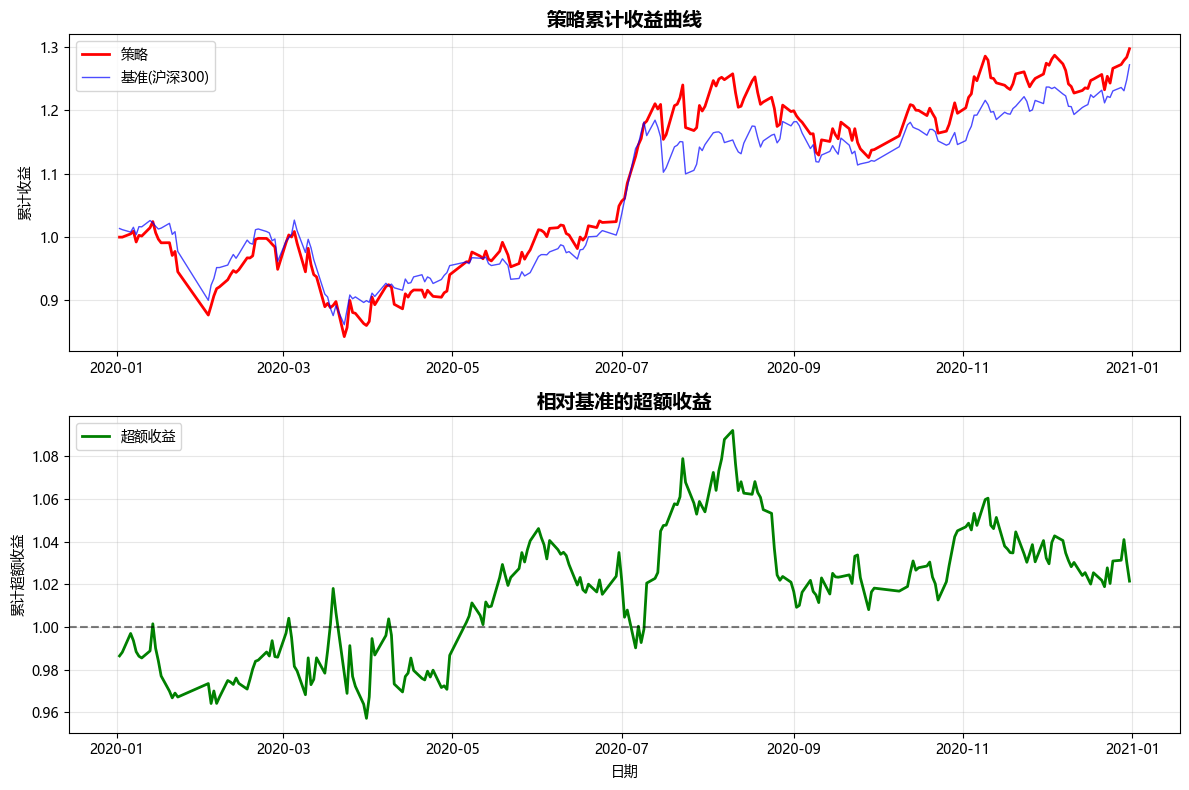

✅ 回测结果可视化完成


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for Chinese display / 配置matplotlib以显示中文
plt.rcParams['font.sans-serif'] = [ 'Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘制回测结果图表
try:
    # 获取分析数据
    if isinstance(indicator, dict):
        analysis_df = pd.DataFrame(indicator) if 'return' in indicator else pd.DataFrame(portfolio_metrics)
    else:
        analysis_df = indicator
    
    if isinstance(analysis_df, pd.DataFrame) and len(analysis_df) > 0:
        # 筛选2020年数据
        if hasattr(analysis_df.index, 'to_timestamp'):
            analysis_df.index = pd.to_datetime(analysis_df.index)
        analysis_2020 = analysis_df.loc["2020-01-01":"2020-12-31"]
        
        if len(analysis_2020) > 0 and 'return' in analysis_2020.columns:
            # 创建双子图
            fig, axes = plt.subplots(2, 1, figsize=(12, 8))
            
            # 上图：累计收益曲线
            ax1 = axes[0]
            cum_return = (1 + analysis_2020['return']).cumprod()
            ax1.plot(cum_return.index, cum_return, label='策略', color='red', linewidth=2)
            
            if 'bench' in analysis_2020.columns:
                cum_bench = (1 + analysis_2020['bench']).cumprod()
                ax1.plot(cum_bench.index, cum_bench, label='基准(沪深300)', color='blue', linewidth=1, alpha=0.7)
            
            ax1.set_ylabel('累计收益')
            ax1.set_title('策略累计收益曲线', fontsize=14, fontweight='bold')
            ax1.legend(loc='upper left')
            ax1.grid(True, alpha=0.3)
            
            # 下图：超额收益或日收益率
            ax2 = axes[1]
            if 'bench' in analysis_2020.columns:
                excess_return = analysis_2020['return'] - analysis_2020['bench']
                excess_cum = (1 + excess_return).cumprod()
                ax2.plot(excess_cum.index, excess_cum, label='超额收益', color='green', linewidth=2)
                ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)
                ax2.set_ylabel('累计超额收益')
                ax2.set_title('相对基准的超额收益', fontsize=14, fontweight='bold')
            else:
                ax2.plot(analysis_2020.index, analysis_2020['return'], label='日收益率', color='purple', linewidth=1)
                ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
                ax2.set_ylabel('日收益率')
                ax2.set_title('策略日收益率', fontsize=14, fontweight='bold')
            
            ax2.set_xlabel('日期')
            ax2.legend(loc='upper left')
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            print("✅ 回测结果可视化完成")
        else:
            print("⚠️ 数据格式不完整，无法绘制图表")
    else:
        print("⚠️ 无有效数据进行可视化")
        
except Exception as e:
    print(f"可视化出错: {e}")

## 附录：常见问题

### Q1: 数据下载失败怎么办？
A: 检查网络连接，或手动从Qlib GitHub仓库下载数据。

### Q2: 内存不足怎么办？
A: 减少股票池范围（如使用csi100而非csi300），或缩短时间窗口。

### Q3: 如何使用自己的数据？
A: 参考Qlib文档的Custom Data章节，需要按照Qlib格式准备数据。

### Q4: 如何改进模型效果？
A: 1) 特征工程 2) 模型调参 3) 集成学习 4) 更长的训练数据

## 总结

🎉 恭喜！你已经完成了一个完整的Qlib量化投资工作流程：

1. ✅ **环境初始化** - 配置Qlib和中文字体
2. ✅ **数据准备** - 下载A股数据和Alpha158特征
3. ✅ **模型训练** - 使用LightGBM预测股票收益
4. ✅ **策略回测** - TopK策略选股和交易
5. ✅ **结果可视化** - 绘制收益曲线和性能图表

### 进阶方向

- **模型优化**：调参、集成学习、深度学习模型
- **特征工程**：自定义因子、多时间框架特征
- **策略改进**：动态仓位、风险控制、多策略组合
- **实盘交易**：接入券商API、实时数据处理

### 相关资源

- [Qlib官方文档](https://qlib.readthedocs.io/)
- [GitHub仓库](https://github.com/microsoft/qlib)
- 更多示例notebook将在后续章节中详细介绍